In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv(r"C:\Users\CT\Downloads\housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
print(df.shape)

df.info()

df.isnull().sum()

(20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
encoder = LabelEncoder()

df["ocean_proximity"] = encoder.fit_transform(df["ocean_proximity"])

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [8]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
print("Intercept:")

print(model.intercept_)

print()

print("Coefficients:")

print(model.coef_)

Intercept:
-3594630.7600683277

Coefficients:
[-4.28077658e+04 -4.25657762e+04  1.18426973e+03 -8.13638808e+00
  1.16392023e+02 -3.85957093e+01  4.62029610e+01  4.05118332e+04
 -3.18827157e+02]


In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 63642.8756283  154445.82484212 252777.76132136 263796.86435521
 266307.35634573 155172.6120045  287374.15466997 223979.21275959
 256629.12515906 404529.43164436]


In [13]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("RMSE =", rmse)

print("R2 Score =", r2)

RMSE = 71147.87146118373
R2 Score = 0.6137068886499537


In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,47700.0,63642.875628
1,45800.0,154445.824842
2,500001.0,252777.761321
3,218600.0,263796.864355
4,278000.0,266307.356346
5,158700.0,155172.612004
6,198200.0,287374.154670
7,157500.0,223979.212760
8,340000.0,256629.125159
9,446600.0,404529.431644


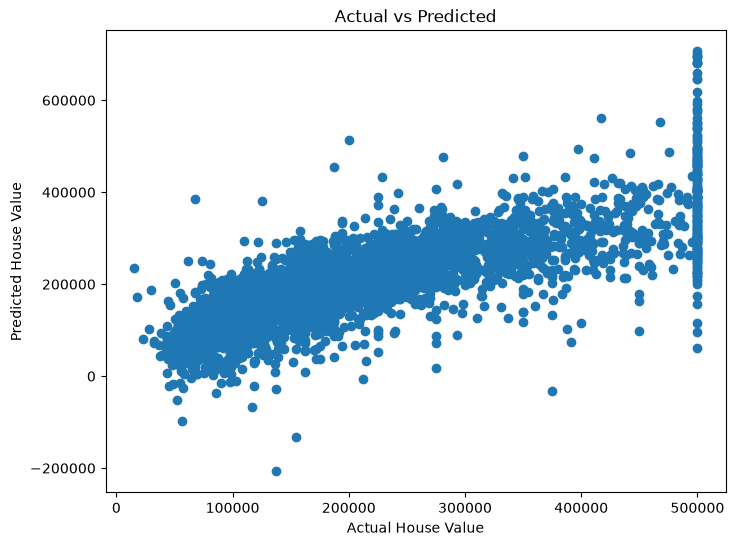

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
customer = pd.read_csv(r"C:\Users\CT\Downloads\mallcustomers.csv)

customer.head()

In [ ]:
X = customer[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
inertia = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans.labels_
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Clusters")

plt.show()

# Regression

I used Linear Regression because the target variable (median_house_value) is continuous. Before training the model, I cleaned the dataset by filling missing values and encoding the categorical column. The model was evaluated using RMSE and R² Score. A lower RMSE indicates better prediction accuracy, while a higher R² Score shows that the model explains more of the variation in house prices.

# Clustering

I used K-Means clustering on Annual Income and Spending Score. The data was scaled using StandardScaler before clustering. I selected 5 clusters after observing the elbow method because the inertia started decreasing more slowly after that point. These clusters represent different customer groups with similar income and spending behavior.

# Regression and Clustering Assignment

## Overview

This project is part of the AI & Machine Learning Internship Week 3 assignment.

## Regression
- Dataset: housing(1).csv
- Model: Linear Regression
- Target: median_house_value
- Evaluation: RMSE and R² Score

## Clustering
- Dataset: Mall_Customers(1).csv
- Algorithm: K-Means
- Features:
  - Annual Income (k$)
  - Spending Score (1-100)

## Libraries
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Author
Abdul Haseeb